# In this model we want to do the following:
- Model the white light curve for both visits
- Use fit results to fix the ramp and breathing parameters

In [2]:
import os
import jax
import jax.numpy as jnp
from jax import pmap, devices

# Force CPU mode to avoid the Metal version mismatch
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=12'

# Clear any cached backends
jax.config.update('jax_platform_name', 'cpu')

# Now check devices
print("Available devices:", devices())
print("CPU devices:", devices('cpu'))

import warnings
warnings.filterwarnings("ignore", message="It appears that you're using a Mac with one of Apple's ARM-based processors")

# We need to import numpyro first (though we use it last)
import numpyro
from numpyro.infer import MCMC, NUTS
from numpyro import distributions as dist
# N_cores = 18
# numpyro.set_host_device_count(N_cores)

from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11)]


2025-09-26 19:57:33,858 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

  0%|          | 0/162 [00:00<?, ?it/s]

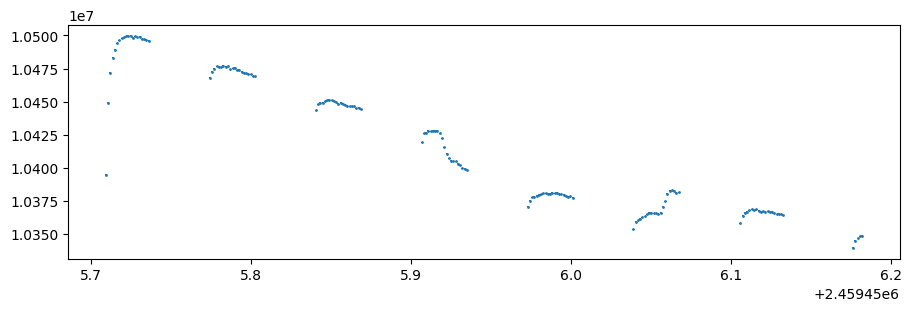

<Figure size 640x480 with 0 Axes>

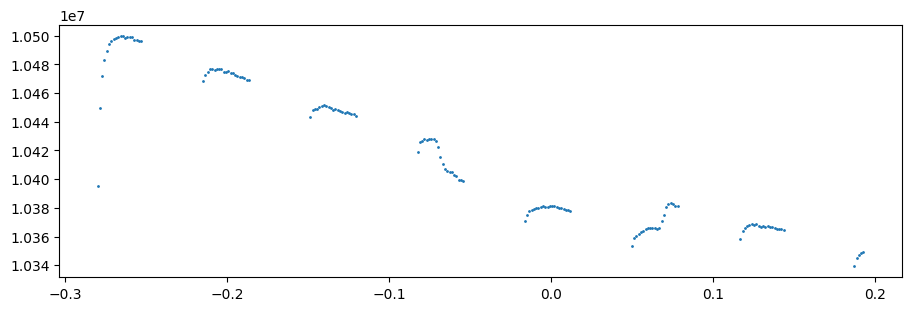

<Figure size 640x480 with 0 Axes>

In [3]:
visit = 'F21'

orbits_to_exclude = np.array([0,2])
err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor
lc_index = 1 if visit=='F21' else 0
bin_edges = jnp.array([0.86,1.138,1.645]) * u.micron

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']

rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
binned_for_model = rainbow.bin(wavelength_edges=bin_edges)
fleck_wavelengths = binned_for_model.wavelength.value

'Adjust uncertainties and bin the rainbow'
for i in range(len(rainbow.wavelength.value)):
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * err_factor[i]

# 'remove the spots'
# trim_spots = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=(predicted_T0+0.027)*u.day, duration=0.075*u.day) )
# trim_spots.imshow()
# plt.show()
# plt.clf()
# trimmed_rainbow = trim_spots.trim().get_average_lightcurve_as_rainbow()
# trimmed_rainbow.time = trimmed_rainbow.time + (predicted_T0+0.027)*u.day
trimmed_rainbow = speclc_rainbow.get_average_lightcurve_as_rainbow()

trimmed_rainbow.time[-12:] = np.nan
# trimmed_rainbow.time[1:12] = np.nan

plt.figure(figsize=(9,3))
plt.errorbar(trimmed_rainbow.time,trimmed_rainbow.flux.flatten(),trimmed_rainbow.uncertainty.flatten(),
            fmt='o',ms=1)
plt.show()
plt.clf()

data_wavelengths = speclc_rainbow.wavelength.value
img_date = trimmed_rainbow.time.value
data_flux = trimmed_rainbow.flux.flatten().value
relative_err = trimmed_rainbow.uncertainty.flatten().value/data_flux
time_from_T0 = img_date - predicted_T0

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

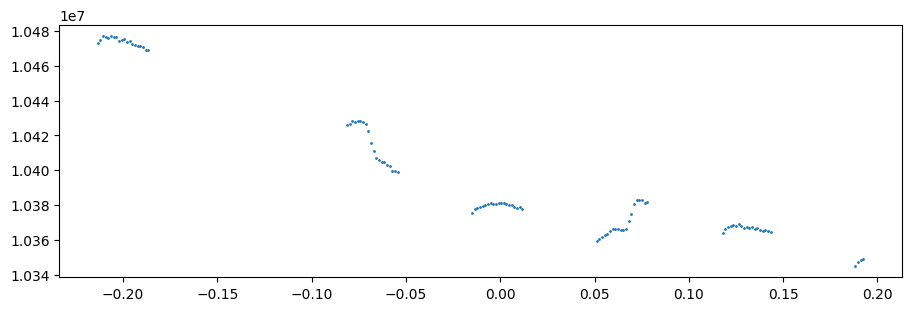

<Figure size 640x480 with 0 Axes>

In [4]:
# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[orbit == orbit_to_exclude] = np.nan
    relative_err[orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,data_flux,yerr=relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

# plt.figure(figsize=(9,3) )
# plt.errorbar(ramp_phase,data_flux,yerr=relative_err,fmt='o',ms=1)
# plt.show()
# plt.clf()

# plt.figure(figsize=(9,3) )
# plt.errorbar(breathing_phase,data_flux,yerr=relative_err,fmt='o',ms=1)
# plt.show()
# plt.clf()

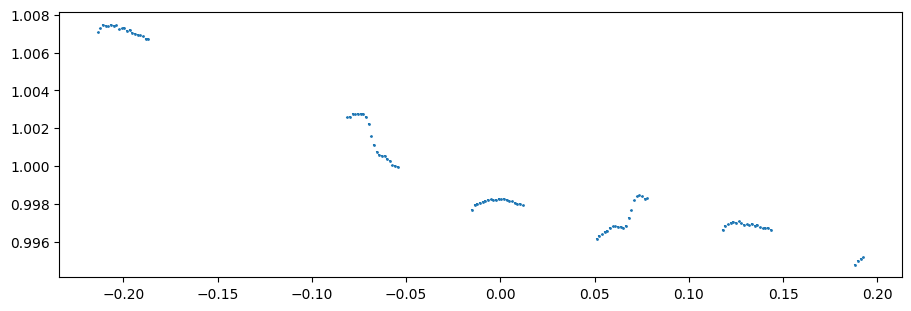

<Figure size 640x480 with 0 Axes>

In [5]:
# Convert all arrays to JAX arrays
_data_flux = jnp.array( data_flux[~np.isnan(time_from_T0)] )
data_flux = _data_flux[~jnp.isnan(_data_flux)]
_relative_err = jnp.array(relative_err[~np.isnan(time_from_T0)] )
relative_err = _relative_err[~jnp.isnan(_data_flux)]
_img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
img_date = _img_date[~jnp.isnan(_data_flux)]
_time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
time_from_T0 = _time_from_T0[~jnp.isnan(_data_flux)]
_ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
ramp_phase = _ramp_phase[~jnp.isnan(_data_flux)]
_breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )
breathing_phase = _breathing_phase[~jnp.isnan(_data_flux)]

normalized_data_flux = data_flux/jnp.mean(data_flux)
normalized_relative_err = relative_err*normalized_data_flux

plt.figure(figsize=(9,3) )
plt.errorbar(time_from_T0,normalized_data_flux,yerr=normalized_relative_err,fmt='o',ms=1)
plt.show()
plt.clf()

In [6]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = numpyro.sample('r_1', dist.Uniform(7.0, 20.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-8, -3))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(-0.005,0.005))

    # Instrument Parameters
    params['b_1'] = 0#numpyro.sample('b_1', dist.Uniform(-1,1))
    params['b_2'] = 0#numpyro.sample('b_2', dist.Uniform(-1,1))
    params['b_3'] = 0#numpyro.sample('b_3', dist.Uniform(-1,1))
    params['b_4'] = 0#numpyro.sample('b_4', dist.Uniform(-1,1))

    # Baseline Parameters
    params['limb_spot_lon'] = numpyro.sample('limb_spot_lon', dist.Uniform(-1.5, -0.6))
    params['limb_spot_lat'] = numpyro.sample('limb_spot_lat', dist.Uniform(1.0, 1.35))
    params['limb_spot_rad'] = numpyro.sample('limb_spot_rad', dist.Uniform(0.1, 0.6))
    
    params['chord_spot_1_lon'] = numpyro.sample('chord_spot_1_lon', dist.Uniform(0.0, 0.15))
    params['chord_spot_1_lat'] = numpyro.sample('chord_spot_1_lat', dist.Uniform(1.35, 1.5))
    params['chord_spot_1_rad'] = numpyro.sample('chord_spot_1_rad', dist.Uniform(0.2, 0.45))

    params['chord_spot_2_lon'] = numpyro.sample('chord_spot_2_lon', dist.Uniform(-1.05,0.95))
    params['chord_spot_2_lat'] = numpyro.sample('chord_spot_2_lat', dist.Uniform(1.6, 1.73))
    params['chord_spot_2_rad'] = numpyro.sample('chord_spot_2_rad', dist.Uniform(0.0, 0.2))

    # Planet Parameters
    params['rp_rs'] = numpyro.sample('rp_rs', dist.Uniform(0.04, 0.048))
    params['t_0'] = 0.0007#numpyro.sample('t_0', dist.Uniform(-0.005, 0.005)) 
    params['a'] = 19.15 #numpyro.sample('a', dist.Uniform(18.0, 20.0))
    
    params['u1'] = 0.25#numpyro.sample('u1', dist.Uniform(0.1,0.6))
    params['u2'] = 0.15#numpyro.sample('u2', dist.Uniform(0.15,0.6))
    
    # Stellar Parameters
    params['T_phot'] = 4200
    params['T_spot'] = 3550 #numpyro.sample('T_spot', dist.Uniform(3400,3600))
    beta = numpyro.sample('beta', dist.Uniform(0, 0.6))

    @jit
    def broadband_transit(params,**kwargs):

        # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        _systematics = (breathing * ramp)
        systematics = _systematics/jnp.mean(_systematics)
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(89.5),
            a = jnp.asarray(params['a'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rs'], dtype=jnp.float64),
            period = 8.46,
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = 0.0,
            u1 = jnp.asarray(params['u1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u2'], dtype=jnp.float64))
        
        # Get spectra for the model temps
        Phot = get_binned_BTSettl_spectrum_jax(T=params['T_phot'],data_wave = fleck_wavelengths)
        Cool = get_binned_BTSettl_spectrum_jax(T=params['T_spot'],data_wave = fleck_wavelengths)
        
        # Update stellar parameters
        active_star = ActiveStar(
            times = time_from_T0,
            inclination=jnp.radians(89.5),
            T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
            wavelength=Phot[0]*1e-6, # m
            phot=Phot[1],
            P_rot=4.863
        )
        
        active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]]),
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([params['T_spot'],params['T_spot'],params['T_spot']]),
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['limb_spot_lon'], params['chord_spot_1_lon'], params['chord_spot_2_lon']]),
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['limb_spot_lat'], params['chord_spot_1_lat'], params['chord_spot_2_lat']]),
        ])
        active_star.rad = jnp.concatenate([
            jnp.array([params['limb_spot_rad'], params['chord_spot_1_rad'], params['chord_spot_2_rad']]),
        ])        
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T[lc_index] * systematics
        mean_per_wavelength = jnp.mean(lc_model)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        "Obs", dist.Normal(
            loc=broadband_transit(params), 
            scale=(10**beta)*normalized_relative_err,
        ), obs=normalized_data_flux
    )

In [7]:
def plot_model(params):

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                    r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                    r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                              b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                              b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                              b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
    _systematics = (breathing * ramp)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(89.5),
        a = jnp.asarray(params['a'], dtype=jnp.float64),
        rp = jnp.asarray(params['rp_rs'], dtype=jnp.float64),
        period = 8.46,
        t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
        ecc = 0.0,
        u1 = jnp.asarray(params['u1'], dtype=jnp.float64),
        u2 = jnp.asarray(params['u2'], dtype=jnp.float64))
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=params['T_phot'],data_wave = fleck_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=params['T_spot'],data_wave = fleck_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination=jnp.radians(89.5),
        T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # m
        phot=Phot[1],
        P_rot=4.863
    )
    
    active_star.spectrum = jnp.concatenate([
    jnp.vstack([Cool[1],Cool[1],Cool[1]]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params['T_spot'],params['T_spot'],params['T_spot']]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params['limb_spot_lon'], params['chord_spot_1_lon'], params['chord_spot_2_lon']]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params['limb_spot_lat'], params['chord_spot_1_lat'], params['chord_spot_2_lat']]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params['limb_spot_rad'], params['chord_spot_1_rad'], params['chord_spot_2_rad']]),
    ])        

    lc, contam, X, Y, spectrum_at_transit = plotting_star.transit_model(**planet_parameters)        
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength

    return active_star, normalized_model, planet_parameters

In [59]:
params = {}

# Instrument Parameters
params['r_1'] = 13
params['r_2'] = -6.5
params['r_3'] = 0.00

# Instrument Parameters
params['b_1'] = 0#0.0278
params['b_2'] = 0#-0.1114
params['b_3'] = 0#0.1542
params['b_4'] = 0#-0.0739

# Transit Parameters
params['rp_rs'] = 0.046
params['t_0'] = 0.0007
params['a'] = 19.15 
params['u1'] = 0.25
params['u2'] = 0.15

# Stellar Parameters
params['T_phot'] = 4200
params['T_spot'] = 3550 

params['limb_spot_lon'] = -1.35 # -1.4 - -0.5
params['limb_spot_lat'] = 1.2 # 1.0 - 1.4
params['limb_spot_rad'] = 0.3 # 0.1-0.6

params['chord_spot_1_lon'] = 0.1 # 0.0-0.15
params['chord_spot_1_lat'] = 1.45 # 1.35-1.5
params['chord_spot_1_rad'] = 0.26 # 0.2 - 0.4

params['chord_spot_2_lon'] = -1.05 # -1.05-1.0
params['chord_spot_2_lat'] = 1.65 # 1.63-1.73
params['chord_spot_2_rad'] = 0.05 # 0-0.25

plotting_star, normalized_model, planet_parameters = plot_model(params)

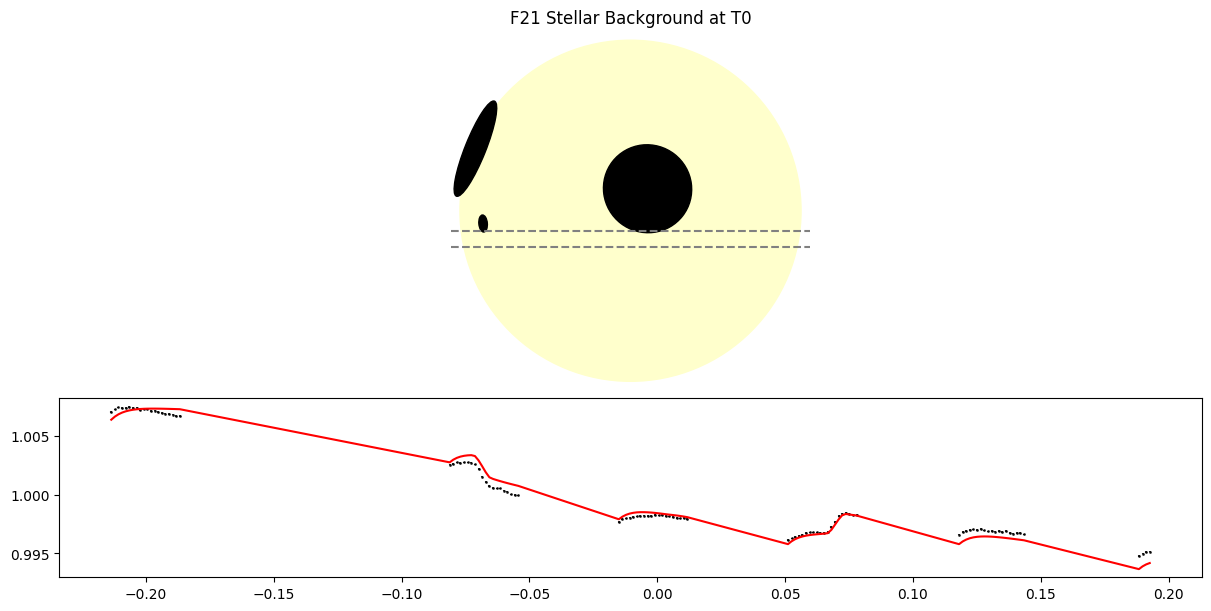

<Figure size 640x480 with 0 Axes>

In [60]:
fig, axs = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': (2, 1)})

'Plot the stellar surface'
plotting_star.plot_star(
    t0=planet_parameters['t0'],
    rp=jnp.mean(planet_parameters['rp']),  # Exoplanet radius in units of stellar radii
    a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
    inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
    ecc=0.0, ax=axs[0])

axs[1].errorbar(time_from_T0, normalized_data_flux, 10**0.3 * normalized_relative_err, fmt='o', color='k', alpha=0.8,ms=1)
axs[1].plot(time_from_T0, normalized_model, color='red',zorder=100)

axs[0].set_title(f'{visit} Stellar Background at T0')

plt.savefig(f'../figs/{visit}_{model_designation}_starmap.png', dpi=250)
plt.show()
plt.clf()

In [ ]:
'Plot the transmission and contamination spectra'
fig, axs = plt.subplots(3,1,figsize=(5,5))
axs[0].set_title('Contaminated Transmission Spectrum')
axs[0].scatter(data_wavelengths, contam * 1e6 ,s=2,color='k')
axs[1].set_title('Stellar Contamination')
axs[1].scatter(data_wavelengths, (contam-planet_parameters['rp']**2)*1e6,s=2,color='k')
axs[2].set_title('De-contaminated Transmission Spectrum')
axs[2].scatter(data_wavelengths, (planet_parameters['rp'])**2 * 1e6,s=2,color='k')
axs[0].set_ylabel('Transit Depth (ppm)')
axs[1].set_ylabel('Transit Depth (ppm)')
axs[2].set_ylabel('Transit Depth (ppm)')
plt.xlabel(r'Wavelength ($\mu$m)')
# plt.savefig(f'../figs/{visit}_{model_designation}_{len(speclc_bin_edges)-1}bins_transmission.png',dpi=250)
plt.show()
plt.clf()

'Set up the data + model plots'
fig, axes = plt.subplots(4, 1, figsize=(8,12))
axes[0].set_title(f"{visit}")
axes[0].set_xlabel("Time from midtransit")
axes[0].set_ylabel("Relative Flux")
axes[1].set_title("Systematic-corrected")
axes[1].set_xlabel("Time from midtransit")
axes[2].set_title("Residuals")
axes[2].set_xlabel("Time from midtransit")
axes[2].set_ylabel(r"$\sigma$")
axes[3].set_title("Residuals")
axes[3].set_xlabel("HST Phase")
axes[3].set_ylabel(r"$\sigma$")

for i, lc_i in enumerate(lc.T):
    lc_i /= np.nanmean(lc_i)
    model_i = systematics * lc_i
    model_i /= np.nanmean(model_i)
    normalized_flux = data_flux[i, :]/np.nanmean(data_flux[i, :])

    # First plot (data + model)
    axes[0].errorbar(
        time_from_T0,
        normalized_flux - (0.0022*i),
        yerr=relative_err[i, :],
        # markeredgecolor='gray',
        alpha=0.7,fmt='o',ms=2.5,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    # Second plot (data & model)/systematics
    axes[1].errorbar(
        time_from_T0,
        (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics) - (0.0022*i),
        yerr=relative_err[i, :],
        # markeredgecolor='gray',
        alpha=0.7,fmt='o',ms=2.5,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    # third plot residuals
    axes[2].scatter(
        time_from_T0,
        (normalized_flux-model_i)/relative_err[i, :]- (3.5*i),
        s=5,
        # edgecolors='black',
        alpha=0.7,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    axes[2].axhline((0 - 3.5 * i),color='k',zorder=-100,alpha=0.5)
    # fourth plot residuals in HST phase
    axes[3].scatter(
        breathing_phase,
        (normalized_flux-model_i)/relative_err[i, :],
        s=5,
        # edgecolors='black',
        alpha=0.7,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    axes[3].axhline(0,color='k',zorder=-100,alpha=0.5)

    # Plot the models
    axes[0].plot(
        time_from_T0,
        model_i - (0.0022*i),
        color='k',zorder=100,alpha=0.7)
    axes[1].plot(
        time_from_T0,
        lc_i - (0.0022*i),
        color='k',zorder=100,alpha=0.7)
if savefigs:
    plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_{len(speclc_bin_edges)-1}bins_specLC.png',dpi=250)
plt.show()
plt.clf()

'Set up the data + model plots'
fig, axes = plt.subplots(4, 1, figsize=(6, 12))
axes[0].set_title(f"{visit}")
axes[0].set_xlabel("Time from midtransit")
axes[0].set_ylabel("Relative Flux")
# axes[0].set_xlim(-0.085,0.085)
axes[1].set_title("De-Trended")
axes[1].set_xlabel("Time from midtransit")
# axes[1].set_xlim(-0.085,0.085)
axes[2].set_title("Residuals")
axes[2].set_xlabel("Time from midtransit")
axes[2].set_ylabel(r"$\sigma$")
# axes[2].set_xlim(-0.085,0.085)
axes[3].set_title("Residuals")
axes[3].set_xlabel("HST Phase")
axes[3].set_ylabel(r"$\sigma$")
axes[0].set_xlim(-0.086,0.086)
axes[1].set_xlim(-0.086,0.086)
axes[2].set_xlim(-0.086,0.086)
axes[3].set_xlim(np.nanmin(breathing_phase),np.nanmax(breathing_phase))
for i, lc_i in enumerate(lc.T):
    lc_i /= np.nanmean(lc_i)
    model_i = systematics * lc_i
    model_i /= np.nanmean(model_i)

    normalized_flux = data_flux[i, :]/np.nanmean(data_flux[i, :])

    # First plot (data + model)
    axes[0].errorbar(
        time_from_T0,
        normalized_flux - (0.0022*i),
        yerr=relative_err[i, :],
        # markeredgecolor='gray',
        alpha=0.7,fmt='o',ms=2.0,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    # Second plot (data & model)/systematics
    axes[1].errorbar(
        time_from_T0,
        (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics) - (0.0022*i),
        yerr=relative_err[i, :],
        # markeredgecolor='gray',
        alpha=0.7,fmt='o',ms=2.0,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    # third plot residuals
    axes[2].scatter(
        time_from_T0,
        (normalized_flux-model_i)/relative_err[i, :]- (3.5*i),
        # edgecolors='black',
        alpha=0.7,s=3,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    axes[2].axhline((0 - 3.5 * i),color='k',zorder=-100,alpha=0.5)
    # fourth plot residuals in HST phase
    axes[3].scatter(
        breathing_phase,
        (normalized_flux-model_i)/relative_err[i, :],
        # edgecolors='black',
        alpha=0.7,s=3,
        color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
    axes[3].axhline(0,color='k',zorder=-100,alpha=0.5)

    # Plot the models
    axes[0].plot(
        time_from_T0,
        model_i - (0.0022*i),
        color='k',zorder=100,alpha=0.7)
    axes[1].plot(
        time_from_T0,
        lc_i - (0.0022*i),
        color='k',zorder=100,alpha=0.7)

if savefigs:
    plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_{len(speclc_bin_edges)-1}bins_zoomedspeclcs.png',dpi=250)
plt.show()
plt.clf()

In [8]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')
    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'chkpt_{self.checkpoint}_corner.png',dpi=200)
    plt.show()

    _result = arviz.from_numpyro(self)
    display(arviz.summary(_result))

    # median_result = arviz.summary(result,focus='median')
    # plot_params = {}

    # plt.figure(figsize=(8,3))
    # plt.errorbar(data_time,data_flux_data_err)
    # plt.plot()
    # plt.suptitle(f'checkpoint {self.checkpoint} Plot')
    # plt.savefig(f'chkpt_{self.checkpoint}_model.png',dpi=200)
    # plt.show()

    with open(f'samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

In [9]:
n_temps = 2
n_spots = 3
n_warmup = 1_000
n_samples = 4_000
n_chains = 10 # 14, 11, 9, 7, 6, 5, 4 (best options, could do a comparison to determine the best)

model_designation = f'{visit}_{n_temps}T_{n_spots}spots_{n_samples}_whitelight_withspots_final'
# model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_whitelight_stellarslope_withspots_final'

In [ ]:
rng_key = PRNGKey(42)

sampler = NUTS(
    numpyro_model,
    dense_mass=True
    # [('r_1','r_2','r_3'),
    #             ('b_1','b_2','b_3','b_4'),
    #             ('u1','u2')        
    # ]
)
mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=10, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

  0%|          | 0/11 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

Corner for checkpoint 0


In [ ]:
'Save the result'
result.to_netcdf(f'../data/samples/{model_designation}')
'Print the summary'
arviz.summary(result)

In [ ]:
'Make a corner plot'
corner.corner(
    result, 
    # var_names=['~offset_G102',
    #                    r'~$\beta_{\rm G102}$',
    #                    r'~$\beta_{\rm G141}$',
    #                    r'~$\sigma_{\rm conv}$'],
    # quiet=True, 
);
plt.savefig(f'../figs/{model_designation}_corner.png',dpi=200)

In [ ]:
median_params = arviz.summary(result,stat_focus='median')['median']

In [ ]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [14]:
import numpy as np
from scipy.stats import gaussian_kde

# Get parameter names
all_vars = result.groups()
print("Available groups:", all_vars)

if 'posterior' in all_vars:
    posterior_vars = list(result.posterior.data_vars.keys())
    print("Posterior parameters:", posterior_vars)
    
    map_estimates = {}
    for param in posterior_vars:
        # Flatten all chains and draws
        samples = result.posterior[param].values.flatten()
        
        # Use KDE to find mode (true MAP)
        kde = gaussian_kde(samples)
        n_points = 1000
        x = np.linspace(samples.min(), samples.max(), n_points)
        density = kde(x)
        map_value = x[density.argmax()]
        map_estimates[param] = map_value
        
        print(f"{param}: {map_value:.4f}")

Available groups: ['posterior', 'log_likelihood', 'sample_stats', 'observed_data']
Posterior parameters: ['beta', 'chord_spot_1_lat', 'chord_spot_1_lon', 'chord_spot_1_rad', 'chord_spot_2_lat', 'chord_spot_2_lon', 'chord_spot_2_rad', 'limb_spot_lat', 'limb_spot_lon', 'limb_spot_rad', 'r_3', 'rp_rs', 'u1', 'u2']
beta: 0.3867
chord_spot_1_lat: 1.5430
chord_spot_1_lon: 0.0755
chord_spot_1_rad: 0.2356
chord_spot_2_lat: 1.6582
chord_spot_2_lon: 0.8641
chord_spot_2_rad: 0.0696
limb_spot_lat: 1.6274
limb_spot_lon: -1.1659
limb_spot_rad: 0.3938
r_3: 0.0033
rp_rs: 0.0443
u1: 0.2190
u2: 0.2445
